## CPU GPU TPU

go更多是用在网页
rust更加安全 
asic是指专用芯片
hpc是高性能计算


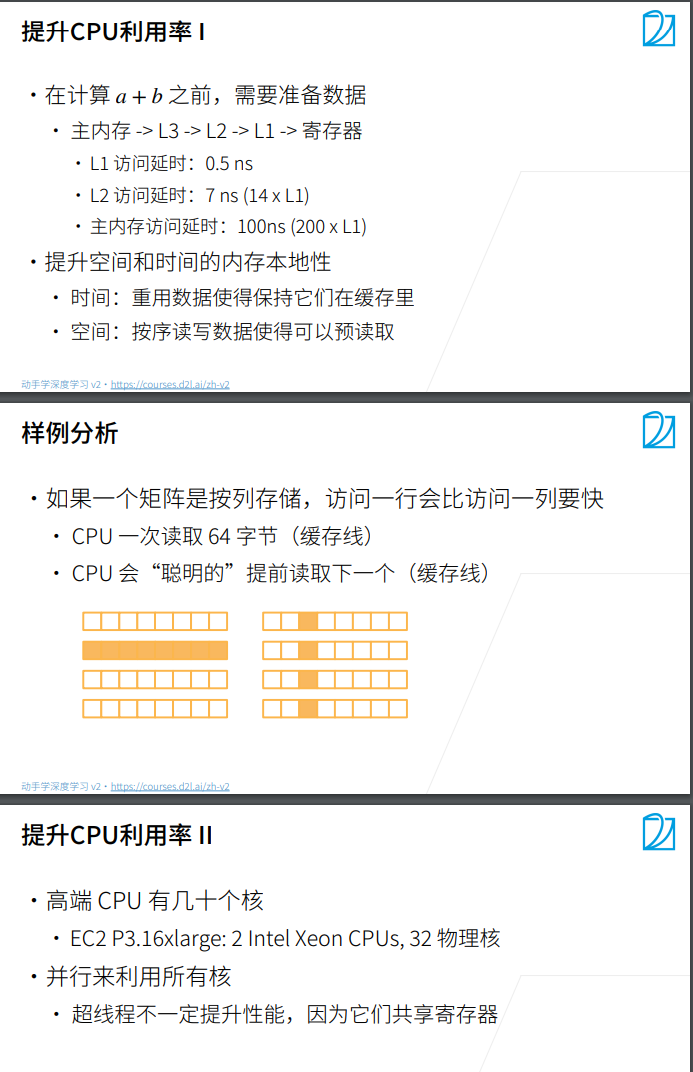
时间上就是放在cache（缓存，发音同cash）里面。第二页ppt打错了 应该是这个矩阵按行存储。LLC是最后一层cache。cpu一般有多层cache，但是显卡的cache层数就较少（方便搬运，速度更快）。
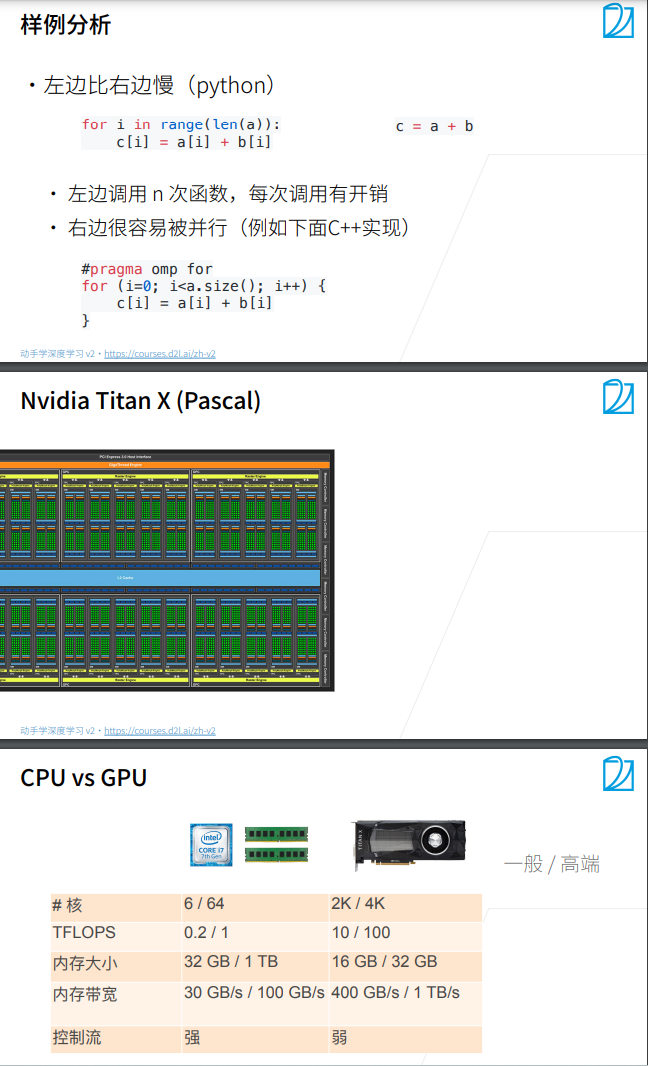
显卡中每个小点就是一个计算单元，可以认为是一个计算核。所以显卡有上千个核，但是cpu一般能64核就不错了。单个cpu核计算能力比显卡的单个计算单元强。但是架不住显卡核多力量大。

cpu做控制 中断很强，是大脑。显卡控制能力较弱。cpu内存大但是带宽低（单位时间能传输的数据），显卡内存小但是带宽高，所以显卡的单位内内存比cpu贵多了。

所以可以多并行来利用显卡（这也意味着矩阵要较大，至少1000维，不然怎么复用上千个核），同时架构更简单易懂数据快。最后要少用控制（if else等语句），因为显卡控制能力差，做控制要整个运算停下等。
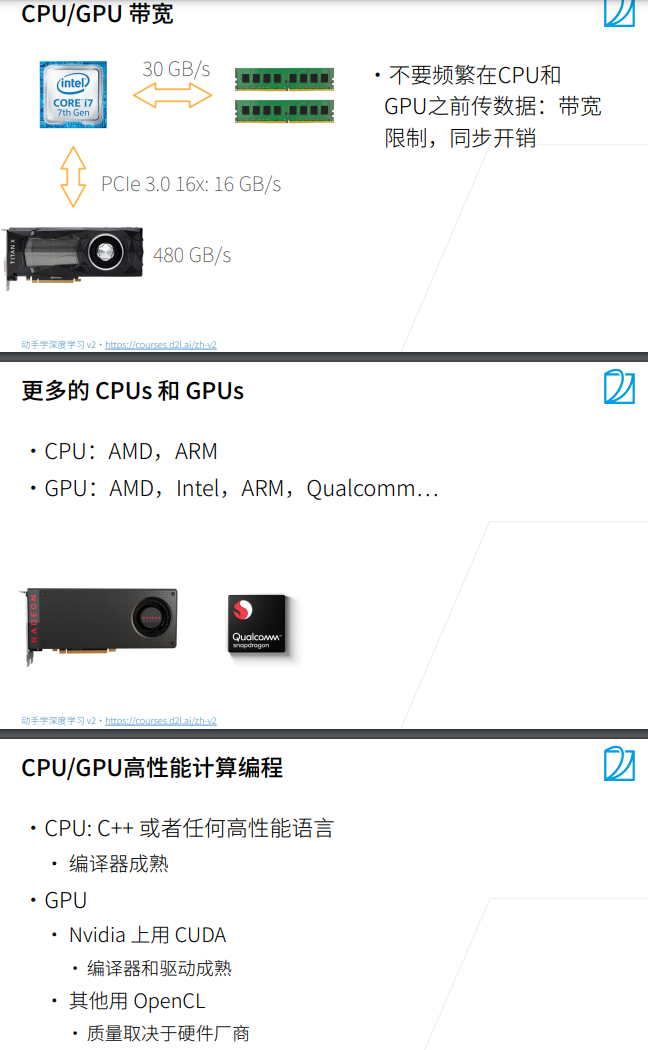
不要频繁的在cpu与gpu之间传输数据

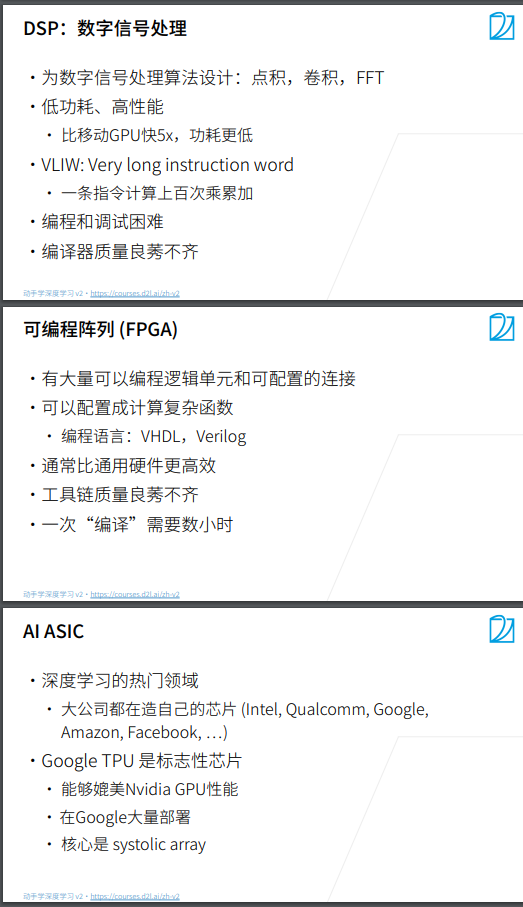
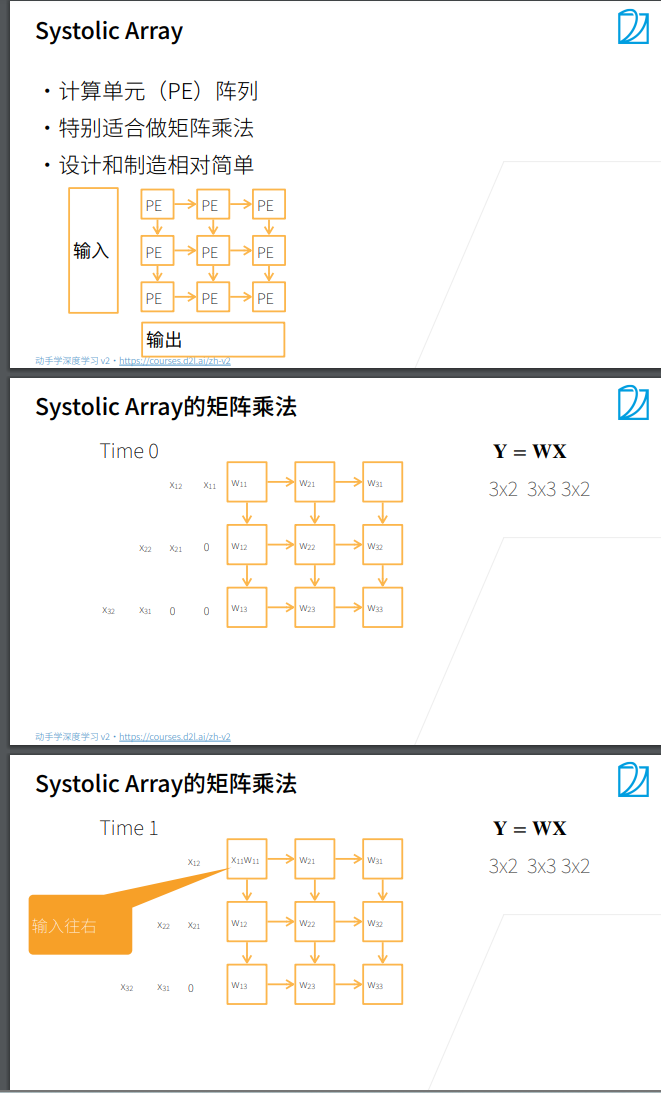

W是转置 X是左右颠倒再补0。systolic array中文名脉动阵列，是tpu中用来计算矩阵运算的。

tpu是一种aigc,主要用于tensorflow,对于transformer特别好用。pytorch可以通过pytorch xla在tpu上使用。tpu的内存特别大，比gpu大多了

edgetpu是指在边缘运行的tpu。在云中运行代码意味着使用的CPU、GPU和TPU都是通过浏览器提供的。边缘与云相反，即在本地运行代码。在边缘运行代码的主要优点是没有网络延迟，由于物联网设备通常要频繁地生成数据，因此运行在边缘上的代码非常适合基于物联网的解决方案。

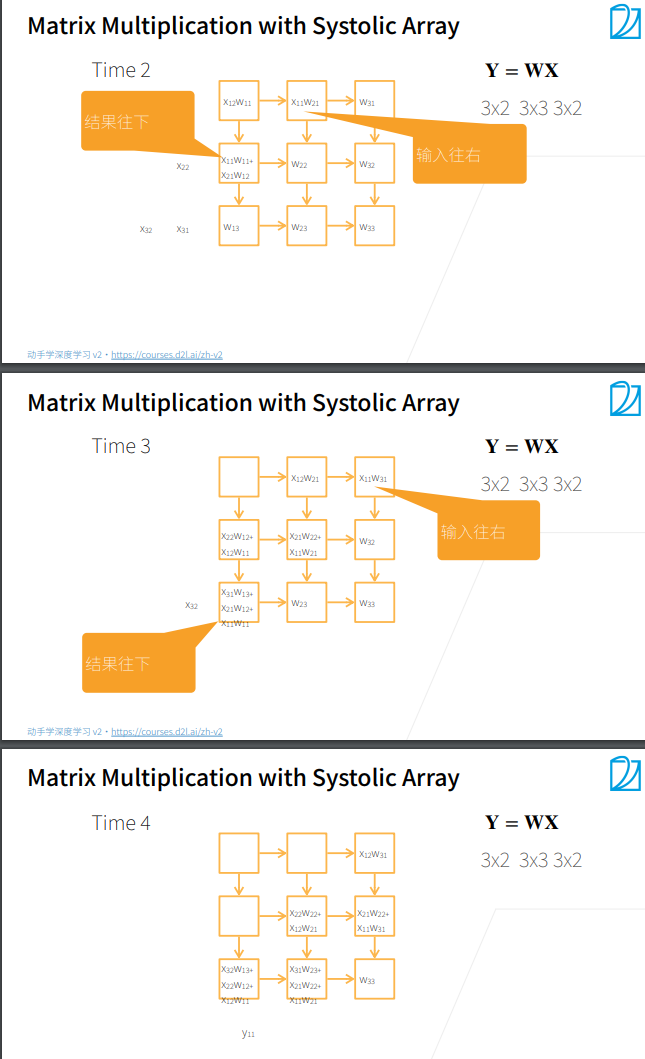
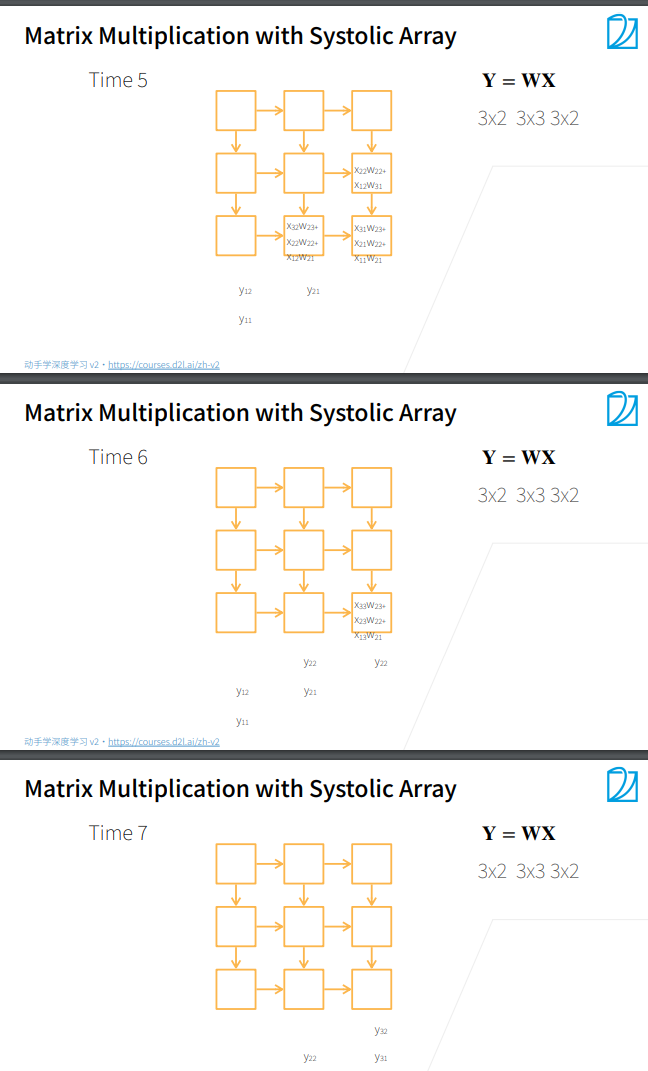

W最后一列写错了 应该是乘以w31

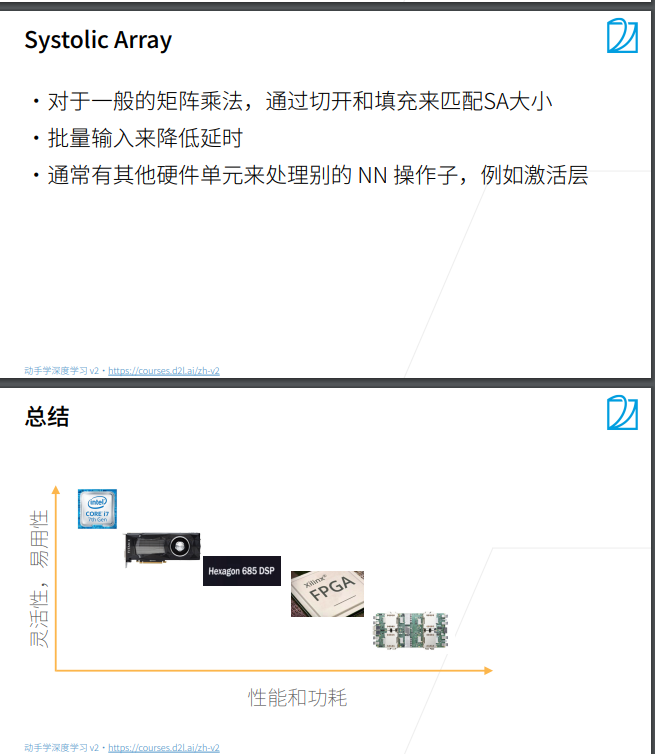

x轴越右边代表功耗越低 性能越好，从左到右分别是cpu gpu dsp fpga tpu

tpu是不关心功耗的，在云端的都不关心功耗，手机、电脑端才关心功耗：1、电量 2、散热（功耗低给予的热量低 不发烫）

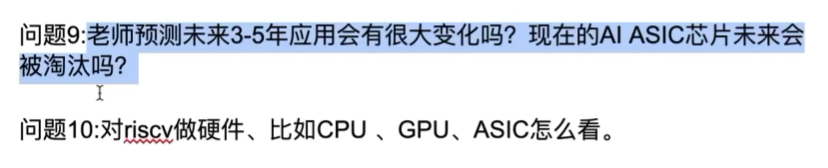
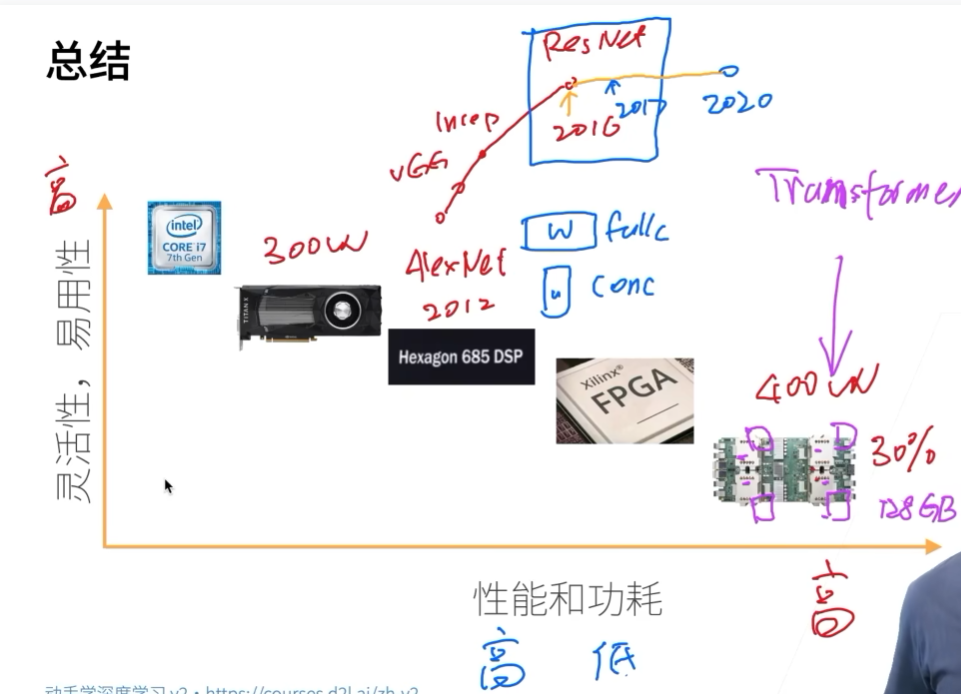
1、我认为是要找准时机，12年开始做芯片 15年出来alexnet早寄了。16开始做，20年出来还能用，不是说淘不淘汰的。

2、https://blog.csdn.net/maopig/article/details/121324070

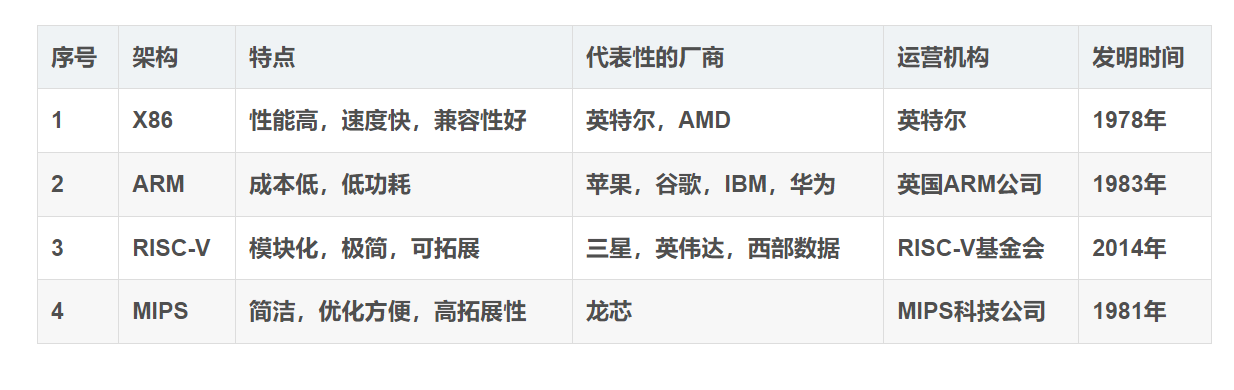
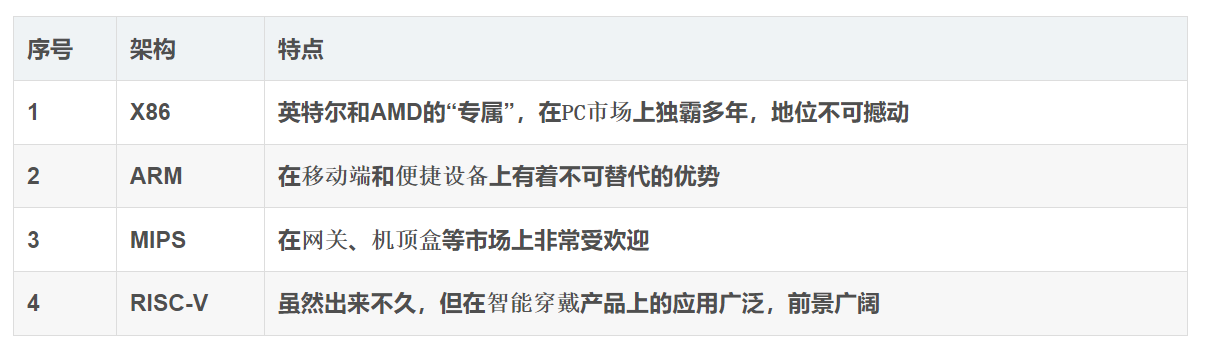

除了x86是cisc（复杂指令集）其他三个都是risc（精简指令集） 各有各的好处 riscV架构主要是便宜

## 单机多卡

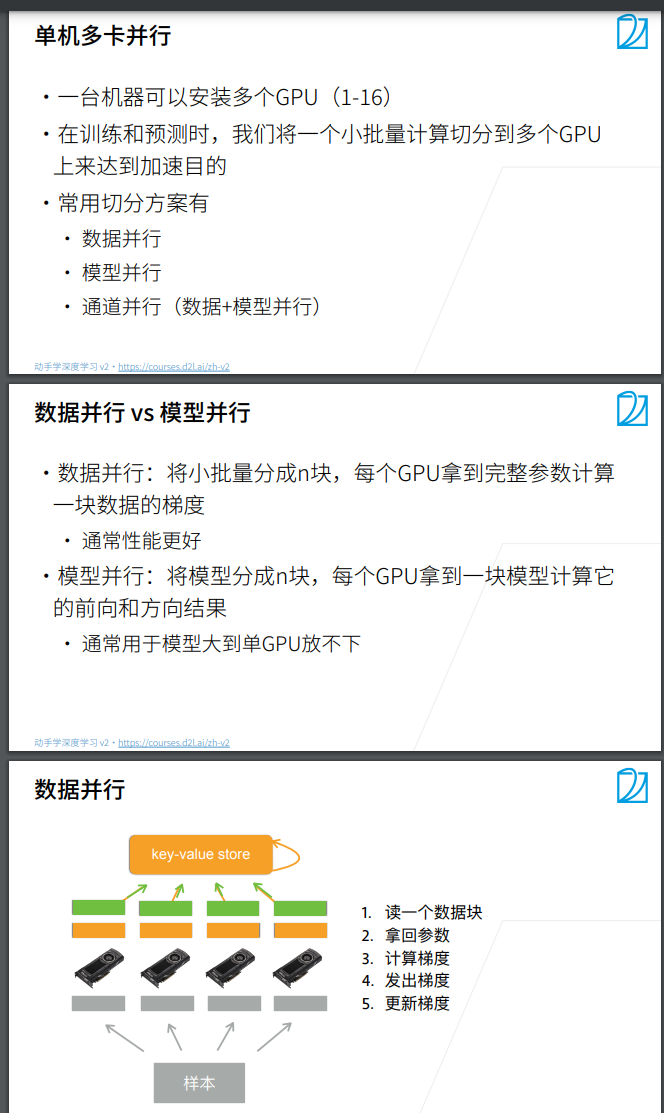
模型并行更像是串行，因为分割了模型，前者算好才能给下一个算

给每个GPU相同的网络参数，然后计算梯度，再将四个梯度加在一起更新网络（因为loss是加的，所以梯度也是加）。key-store一般在cpu中，存储网络的参数。

## 多GPU训练实现
### 从零开始

In [2]:
%matplotlib inline
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

In [3]:
# 初始化模型参数
scale = 0.01
W1 = torch.randn(size=(20, 1, 3, 3)) * scale  # 说明是3*3的卷积核  20是输出通道数 1是输入通道数
b1 = torch.zeros(20)
W2 = torch.randn(size=(50, 20, 5, 5)) * scale
b2 = torch.zeros(50)
W3 = torch.randn(size=(800, 128)) * scale # 线性层
b3 = torch.zeros(128)
W4 = torch.randn(size=(128, 10)) * scale
b4 = torch.zeros(10)
params = [W1, b1, W2, b2, W3, b3, W4, b4]

# 定义模型
def lenet(X, params):
    h1_conv = F.conv2d(input=X, weight=params[0], bias=params[1])# 默认padding为0 stride为1
    h1_activation = F.relu(h1_conv)
    h1 = F.avg_pool2d(input=h1_activation, kernel_size=(2, 2), stride=(2, 2))
    h2_conv = F.conv2d(input=h1, weight=params[2], bias=params[3])
    h2_activation = F.relu(h2_conv)
    h2 = F.avg_pool2d(input=h2_activation, kernel_size=(2, 2), stride=(2, 2))
    h2 = h2.reshape(h2.shape[0], -1) # flatten
    h3_linear = torch.mm(h2, params[4]) + params[5]
    h3 = F.relu(h3_linear)
    y_hat = torch.mm(h3, params[6]) + params[7]
    return y_hat

# 交叉熵损失函数
loss = nn.CrossEntropyLoss(reduction='none')

In [50]:
a= torch.arange(3*18*10).reshape(1,3,18,10)
torch.mm(a,torch.arange(20).reshape(10,2))

RuntimeError: self must be a matrix

In [4]:
def get_params(params, device):
    new_params = [p.to(device) for p in params]
    for p in new_params:
        p.requires_grad_()
    return new_params

In [5]:
new_params = get_params(params, d2l.try_gpu(0))
print('b1 权重:', new_params[1])
print('b1 梯度:', new_params[1].grad)

b1 权重: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       device='cuda:0', requires_grad=True)
b1 梯度: None


In [53]:
len(torch.arange(40).reshape(2,4,5)) # 第0维的大小

2

In [6]:
def allreduce(data):
    for i in range(1, len(data)):
        data[0][:] += data[i].to(data[0].device) 
        # data[0] += data[i].to(data[0].device) 也可以 因为已经有+=了 节约内存了
    for i in range(1, len(data)):
        data[i][:] = data[0].to(data[i].device) # 这里[:]能够节约内存

In [7]:
data = [torch.ones((1, 2), device=d2l.try_gpu(i)) * (i + 1) for i in range(2)]
print('allreduce之前：\n', data[0], '\n', data[1])
allreduce(data)
print('allreduce之后：\n', data[0], '\n', data[1])

allreduce之前：
 tensor([[1., 1.]], device='cuda:0') 
 tensor([[2., 2.]])
allreduce之后：
 tensor([[3., 3.]], device='cuda:0') 
 tensor([[3., 3.]])


In [54]:
a=torch.ones((2, 2))[0]
a

tensor([1., 1.])

In [9]:
torch.ones((1, 2))[0][:]

tensor([1., 1.])

In [11]:
a is a[:] 

False

In [12]:
id(a)

2522322168384

In [13]:
a+=1

In [14]:
id(a)

2522322168384

In [18]:
a[:] = a+1
id(a)

2522322168384

In [19]:
a=a+1
id(a)  # +=和【：】都是在原先的内存上 能够节约内存，而a=a+1这样的式子会多给内存

2523186260784

In [20]:
a[:] = 1
id(a)

2523186260784

In [21]:
a

tensor([1., 1.])

In [22]:
a = 1
id(a)

2523110271280

In [3]:
import torch
from torch import nn

In [4]:
data = torch.arange(20).reshape(2,2,1, 5)
devices = [torch.device('cuda:0'), torch.device('cuda:0')] 
# 这里应该是cuda:1,但我只有1个gpu 所以写了0 否则会报错
split = nn.parallel.scatter(data, devices)
print('input :', data)
print('load into', devices)
print('output:', split) # 会将第0维分成2个部分

input : tensor([[[[ 0,  1,  2,  3,  4]],

         [[ 5,  6,  7,  8,  9]]],


        [[[10, 11, 12, 13, 14]],

         [[15, 16, 17, 18, 19]]]])
load into [device(type='cuda', index=0), device(type='cuda', index=0)]
output: (tensor([[[[0, 1, 2, 3, 4]],

         [[5, 6, 7, 8, 9]]]], device='cuda:0'), tensor([[[[10, 11, 12, 13, 14]],

         [[15, 16, 17, 18, 19]]]], device='cuda:0'))


In [35]:
data = torch.arange(20).reshape(4, 5)
devices = [torch.device('cuda:0'), torch.device('cuda:0')] 
# 这里应该是cuda:1,但我只有1个gpu 所以写了0 否则会报错
split = nn.parallel.scatter(data, devices)
print('input :', data)
print('load into', devices)
print('output:', split)

input : tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]])
load into [device(type='cuda', index=0), device(type='cuda', index=0)]
output: (tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]], device='cuda:0'), tensor([[10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]], device='cuda:0'))


In [25]:
torch.device('cuda:0')

device(type='cuda', index=0)

In [33]:
torch.device('cpu')

device(type='cpu')

In [36]:
#@save  首先要让数据和标签的batch数目一样 然后分别进行分割
def split_batch(X, y, devices):
    """将X和y拆分到多个设备上"""
    assert X.shape[0] == y.shape[0]
    return (nn.parallel.scatter(X, devices),
            nn.parallel.scatter(y, devices))

In [43]:
def train_batch(X, y, device_params, devices, lr):
    X_shards, y_shards = split_batch(X, y, devices)
    # 在每个GPU上分别计算损失
    ls = [loss(lenet(X_shard, device_W), y_shard).sum() 
          # sum以后作为一个元素 这个list里面每个元素是这个gpu的loss和
          for X_shard, y_shard, device_W in zip(
              X_shards, y_shards, device_params)]
    for l in ls:  # 反向传播在每个GPU上分别执行
        l.backward() #计算梯度
    # 将每个GPU的所有梯度相加，并将其广播到所有GPU
    with torch.no_grad():
        for i in range(len(device_params[0])): # 拿出第一组gpu里面的参数个数  每个gpu的参数个数是相同的
            allreduce(
                [device_params[c][i].grad for c in range(len(devices))])
    # 在每个GPU上分别更新模型参数
    for param in device_params:
        d2l.sgd(param, lr, X.shape[0]) # 在这里，我们使用全尺寸的小批量 模拟step

In [41]:
[torch.arange(i).sum() for i in range(5)]

[tensor(0), tensor(0), tensor(1), tensor(3), tensor(6)]

In [47]:
def train(num_gpus, batch_size, lr):
    train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
    devices = [d2l.try_gpu(i) for i in range(num_gpus)]
    # 将模型参数复制到num_gpus个GPU
    device_params = [get_params(params, d) for d in devices] # 注意 这里有num_gpus组一模一样的网络数据 
    num_epochs = 10
    animator = d2l.Animator('epoch', 'test acc', xlim=[1, num_epochs])
    timer = d2l.Timer()
    for epoch in range(num_epochs):
        timer.start()
        for X, y in train_iter:
            # 为单个小批量执行多GPU训练
            train_batch(X, y, device_params, devices, lr)
            torch.cuda.synchronize() # 用来计算时间

        timer.stop()
        # 在GPU0上评估模型
        animator.add(epoch + 1, (d2l.evaluate_accuracy_gpu(
            lambda x: lenet(x, device_params[0]), test_iter, devices[0]),))
    print(f'测试精度：{animator.Y[0][-1]:.2f}，{timer.avg():.1f}秒/轮，'
          f'在{str(devices)}')
'''在GPU执行计算时，通常是异步的，也就是说，计算任务被提交到GPU后，程序并不会等待GPU完成计算，
而是立即返回控制权给CPU，继续执行后面的代码。这种异步的计算方式可以提高程序的效率，
但也会带来一些问题，比如在GPU计算尚未完成时，CPU就开始访问GPU的计算结果，此时可能会得到错误的结果。

为了避免这种问题，可以使用torch.cuda.synchronize()函数来同步CPU和GPU之间的计算。这个函数会阻塞CPU线程，
直到所有在当前设备上排队的CUDA核心完成执行为止。这样，当torch.cuda.synchronize()函数返回时，
我们可以确保GPU的计算已经完成，并且数据已经准备好被CPU使用。
————————————————                        
原文链接：https://blog.csdn.net/qq_45058745/article/details/131765789'''

'在GPU执行计算时，通常是异步的，也就是说，计算任务被提交到GPU后，程序并不会等待GPU完成计算，\n而是立即返回控制权给CPU，继续执行后面的代码。这种异步的计算方式可以提高程序的效率，\n但也会带来一些问题，比如在GPU计算尚未完成时，CPU就开始访问GPU的计算结果，此时可能会得到错误的结果。\n\n为了避免这种问题，可以使用torch.cuda.synchronize()函数来同步CPU和GPU之间的计算。这个函数会阻塞CPU线程，\n直到所有在当前设备上排队的CUDA核心完成执行为止。这样，当torch.cuda.synchronize()函数返回时，\n我们可以确保GPU的计算已经完成，并且数据已经准备好被CPU使用。\n————————————————                        \n原文链接：https://blog.csdn.net/qq_45058745/article/details/131765789'

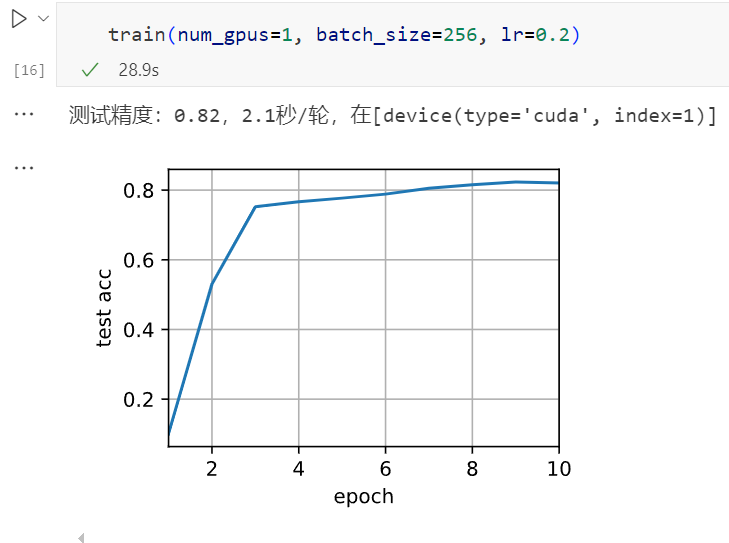
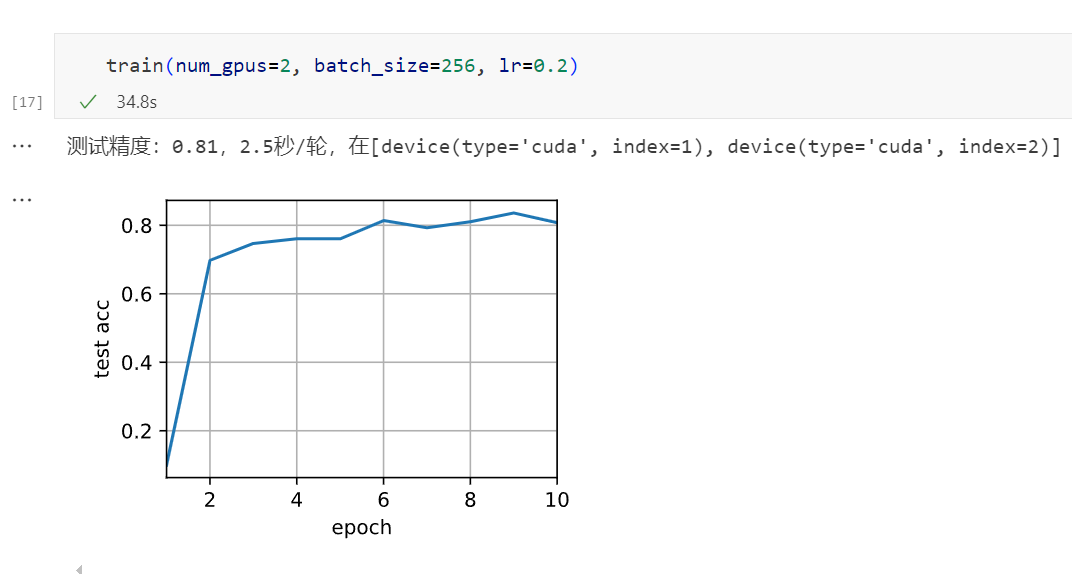
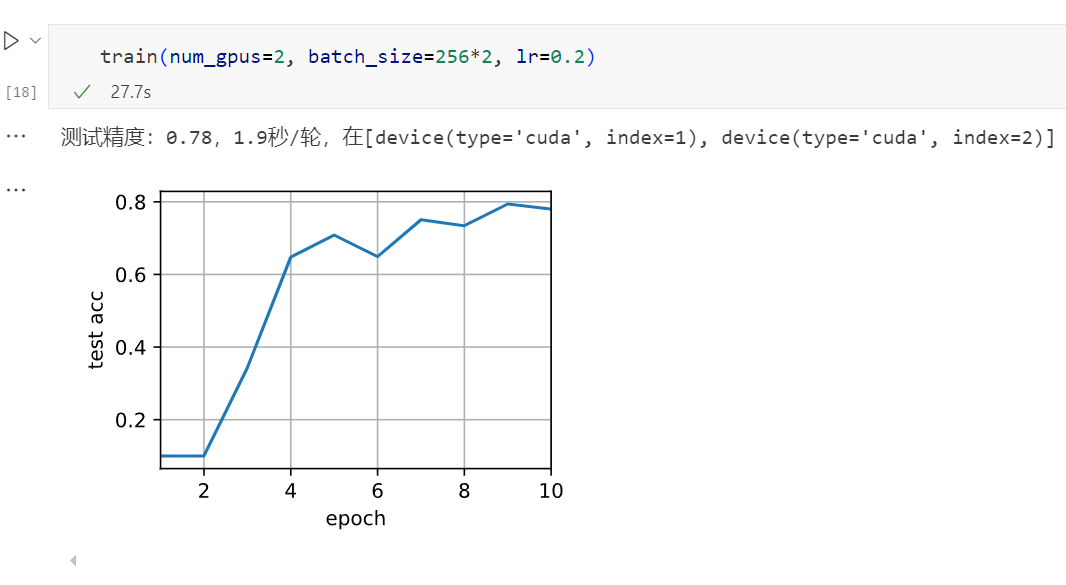
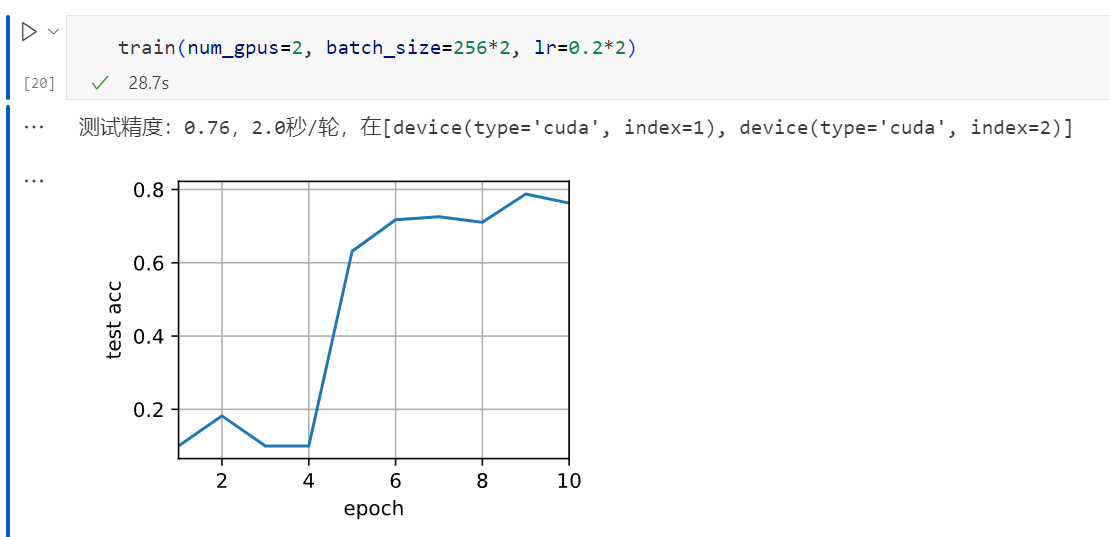
2个GPU没有变快。可能是data拿进来就需要2秒左右时间 所以对于性能的提升不大

还有就是一个gpu只有一半的batchsize了，lenet太简单，导致计算性能变低，gpu几千个性能无法完全利用

还有就是其实代码有点串联的味道，pytorch对于并行的处理不好（如果框架合适是能够合理并行的）

若模型变得更复杂点就能体现出区别，接下来使用更复杂的resnet来进行简明实现

### 简明实现

In [5]:
import torch
from torch import nn
from d2l import torch as d2l

In [20]:
#@save
def resnet18(num_classes, in_channels=1):
    """稍加修改的ResNet-18模型"""
    def resnet_block(in_channels, out_channels, num_residuals,
                     first_block=False):
        blk = []
        for i in range(num_residuals):
            if i == 0 and not first_block:
                blk.append(d2l.Residual(out_channels,
                                        True, 2))
            else:
                blk.append(d2l.Residual(out_channels))
        return nn.Sequential(*blk)

    # 该模型使用了更小的卷积核、步长和填充，而且删除了最大汇聚层
    net = nn.Sequential(
        nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU())
    net.add_module("resnet_block1", resnet_block(
        64, 64, 2, first_block=True))
    net.add_module("resnet_block2", resnet_block(64, 128, 2))
    net.add_module("resnet_block3", resnet_block(128, 256, 2))
    net.add_module("resnet_block4", resnet_block(256, 512, 2))
    net.add_module("global_avg_pool", nn.AdaptiveAvgPool2d((1,1)))
    net.add_module("fc", nn.Sequential(nn.Flatten(),
                                       nn.Linear(512, num_classes)))
    return net

In [24]:
def train(net, num_gpus, batch_size, lr):
    train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
    devices = [d2l.try_gpu(i) for i in range(num_gpus)]
    def init_weights(m):
        if type(m) in [nn.Linear, nn.Conv2d]:
            nn.init.normal_(m.weight, std=0.01)
    net.apply(init_weights)
    # 在多个GPU上设置模型
    net = nn.DataParallel(net, device_ids=devices) # 主要的区别
    trainer = torch.optim.SGD(net.parameters(), lr)
    loss = nn.CrossEntropyLoss()
    timer, num_epochs = d2l.Timer(), 10
    animator = d2l.Animator('epoch', 'test acc', xlim=[1, num_epochs])
    for epoch in range(num_epochs):
        net.train()
        timer.start()
        for X, y in train_iter:
            trainer.zero_grad()
            X, y = X.to(devices[0]), y.to(devices[0]) # 放到一个地方 否则会报错 26行的错
            l = loss(net(X), y)
            l.backward()
            trainer.step()
        timer.stop()
        animator.add(epoch + 1, (d2l.evaluate_accuracy_gpu(net, test_iter),))
    print(f'测试精度：{animator.Y[0][-1]:.2f}，{timer.avg():.1f}秒/轮，'
          f'在{str(devices)}')

In [25]:
net = resnet18(10)
# 获取GPU列表
devices = d2l.try_all_gpus()
# 我们将在训练代码实现中初始化网络

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument target in method wrapper_CUDA_nll_loss_forward)

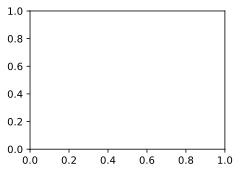

In [26]:
train(net, num_gpus=1, batch_size=256, lr=0.1)

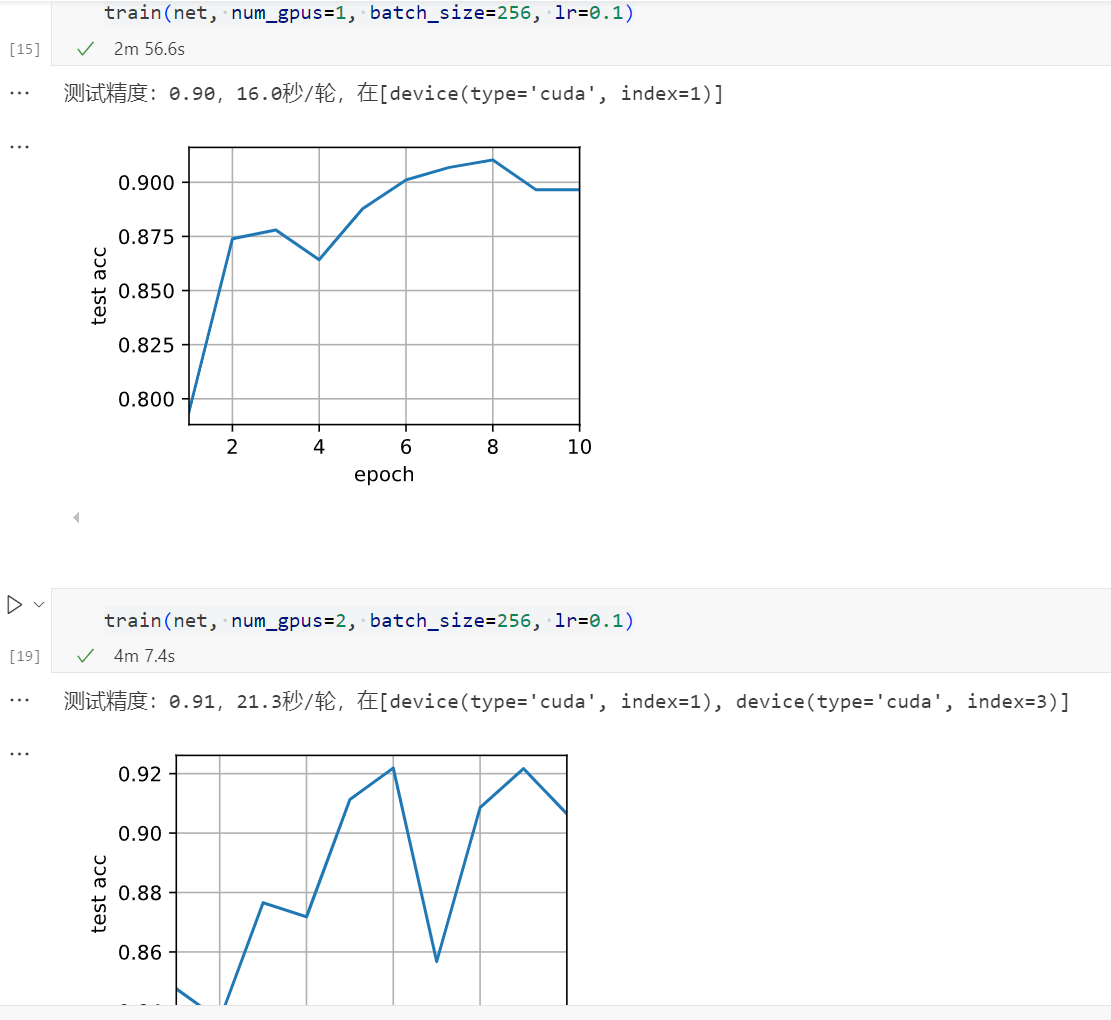
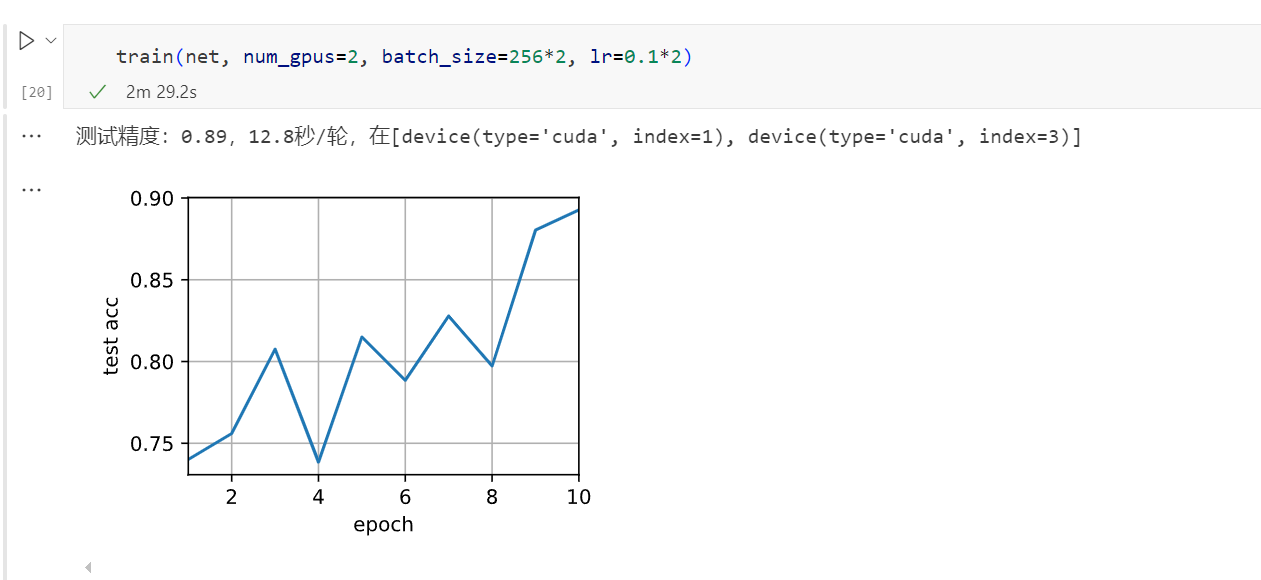

一般多几倍的gpu。为了提高速度，学习率 batch也要多几倍，学习率变大一般会更加抖动，但速度会变快。加入batch 学习率不变，理论上测试精度不会发生变化的。

时间没有除以2，说明整体的通信开销还是大于计算开销。精度降低了一点，可能是batchsize太高了，相似的样本太多了，浪费了时间，并且梯度每次得到的重复了，同时总的轮次就少了，就训练的不充分，容易过拟合。一般多样性比较多，种类比较多，batchsize才会相应增大

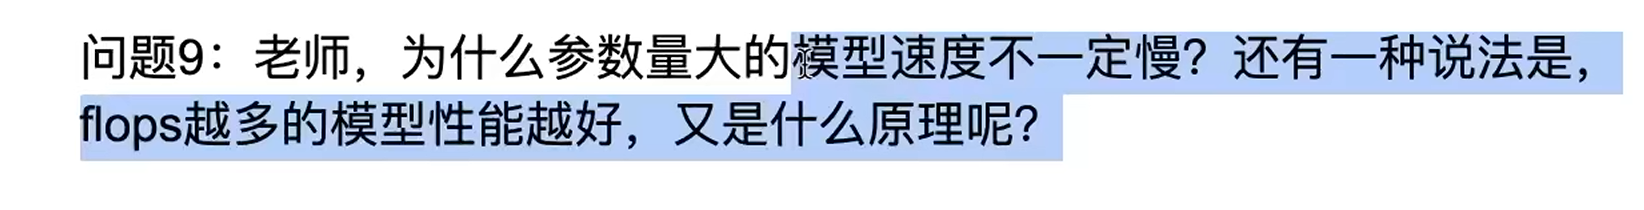
因为要看算一个东西 要访问多少数据。cpugpu一般不卡在频率上，一般卡在访问数据，也就是要看带宽

### 分布式计算
和前面的单机多卡不同，是个一个更大的计算机网络。有多个机器
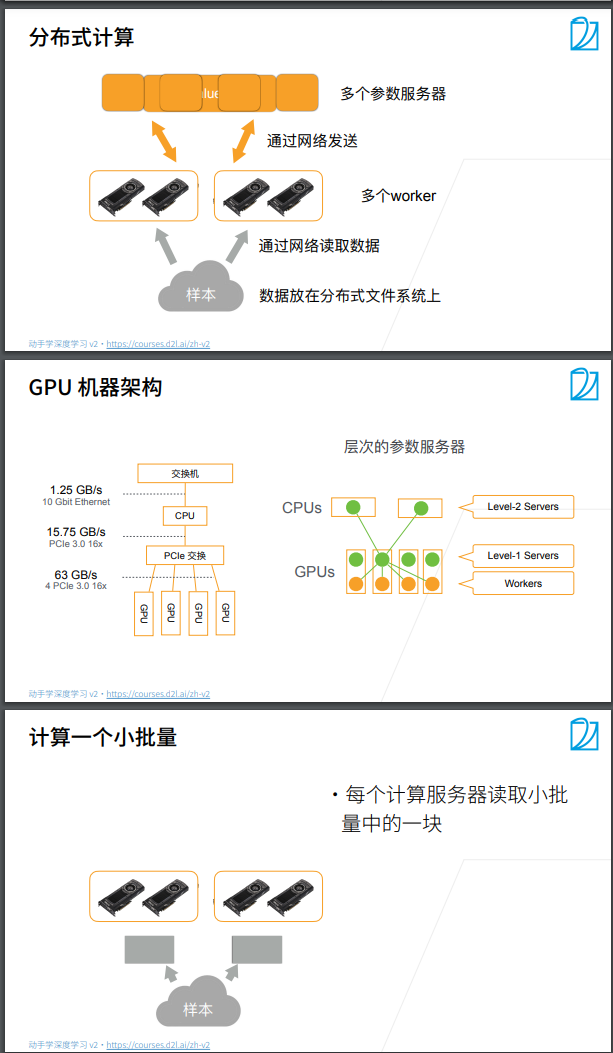
可以看到GPU的带宽是最高的 然后逐渐减少
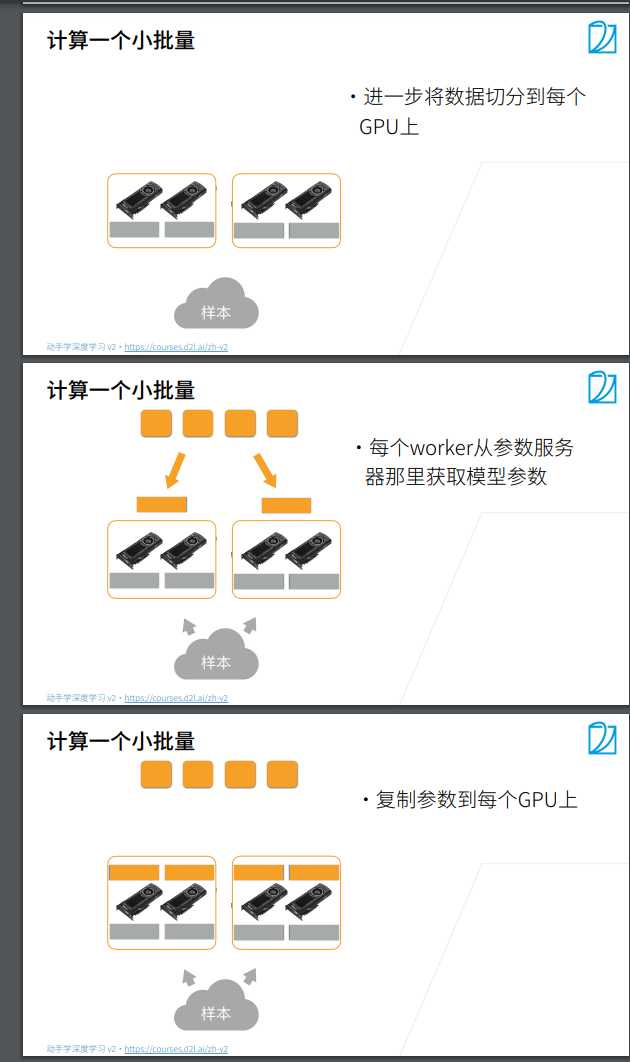
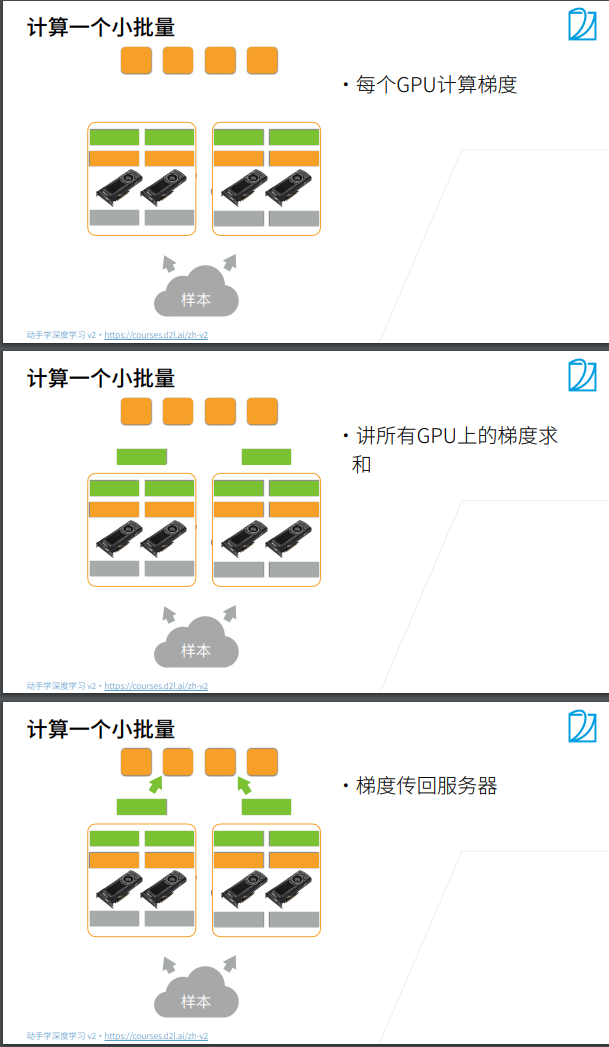
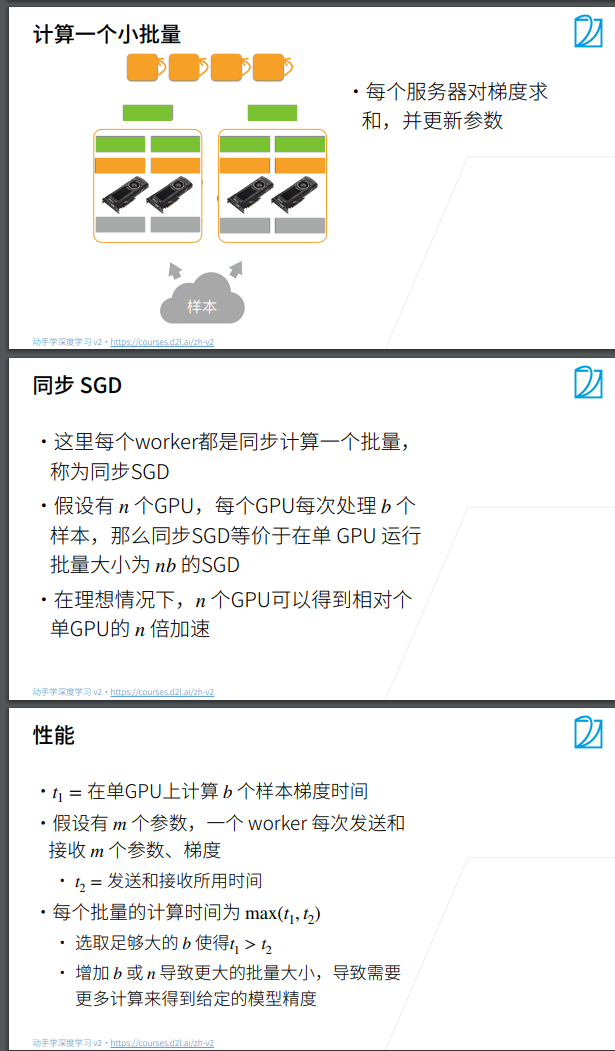
原本就一个gpu单位时间处理b个样本，现在有n个了，速度也就快了n倍（理论上）

一般是收发的通信时间t2作为一个门槛卡住了时间，所以我们一般会加大b使得t1比t2大20~30%
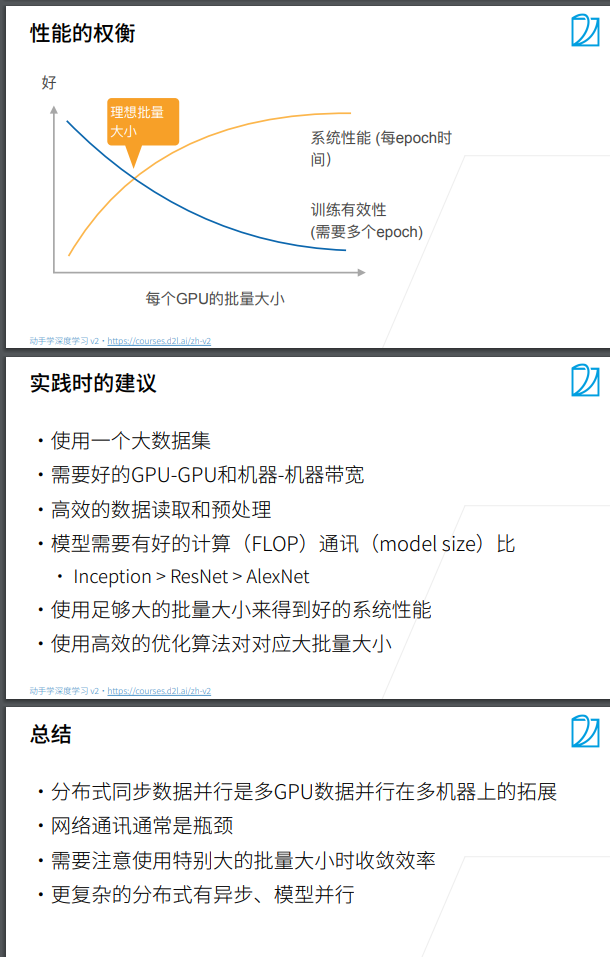
曲线的理解：batch增大，每个epoch需要处理的样本也就多，所以每epoch时间会变大

但是batch太大，就会有很多相似数据的重复，训练有效性降低了，我们一般取交点。如何理解：假设有10000张一模一样的图片，训练100次能收敛，batchsize=1，训练100次就收敛了。若size为10，也依然是100次收敛（因为step的时候除以batchsize），那就是要1000个数据，显然有效性就降低了。

一般来说batchsize最高是样本类别数的10类，其实batchsize的选取更多的和显存有关，显存一般会卡住batch的大小

Flop和modelsize比就是单位计算所需要的参数越少越好（所以这个比越大越好）